<a href="https://colab.research.google.com/github/AyanS13/random_stuff/blob/main/Echelle_spectrograph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

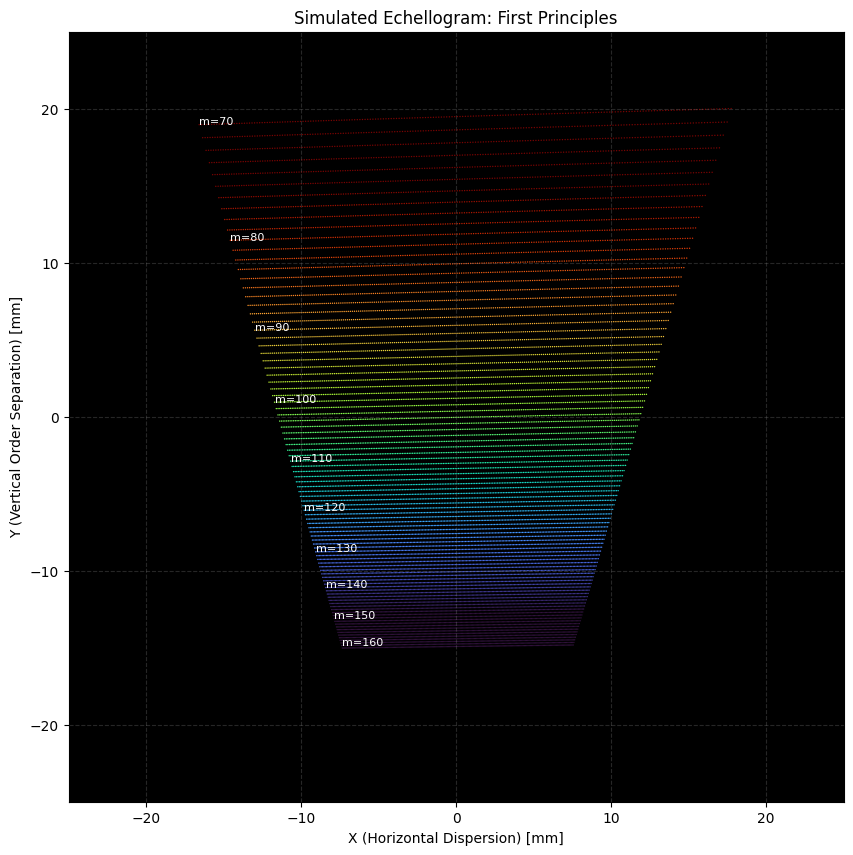

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_echelle():
    # --- 1. Parameters (SI Units) ---
    g_echelle = 31.6 * 1000  # lines per meter
    d_echelle = 1.0 / g_echelle
    theta_blaze = np.radians(63.4)  # R2 grating
    alpha_echelle = theta_blaze  # Littrow configuration

    g_cross = 150 * 1000  # lines per meter (Cross disperser)
    d_cross = 1.0 / g_cross
    alpha_cross = np.radians(0)
    m_cross = 1

    f_cam = 0.5  # 500mm focal length
    det_size = 0.050 # 50mm detector

    # Wavelength range: Visible (400nm to 800nm)
    # Calculate orders m that correspond to visible light for this grating
    # m = 2*d*sin(theta)/lambda
    m_min = int(2 * d_echelle * np.sin(theta_blaze) / 800e-9)
    m_max = int(2 * d_echelle * np.sin(theta_blaze) / 350e-9)
    orders = range(m_min, m_max + 1)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_facecolor('black')

    for m in orders:
        # Blaze wavelength for this order
        lambda_c = (2 * d_echelle * np.sin(theta_blaze)) / m
        fsr = lambda_c / m

        # Array of wavelengths covering the FSR plus a bit of overlap
        waves = np.linspace(lambda_c - 0.6*fsr, lambda_c + 0.6*fsr, 200)

        # Horizontal Dispersion (Echelle)
        # sin(beta) = m*lambda/d - sin(alpha)
        sin_beta_ech = (m * waves / d_echelle) - np.sin(alpha_echelle)

        # Mask valid angles (sin must be between -1 and 1)
        valid = np.abs(sin_beta_ech) < 0.99
        if not np.any(valid): continue

        beta_ech = np.arcsin(sin_beta_ech[valid])
        x = f_cam * (beta_ech - alpha_echelle) # Small angle approx for tan

        # Vertical Dispersion (Cross Disperser)
        sin_beta_cross = (m_cross * waves[valid] / d_cross) - np.sin(alpha_cross)
        beta_cross = np.arcsin(sin_beta_cross)

        # Center the y-axis around the middle of the visible range (~550nm)
        beta_ref = np.arcsin(m_cross * 550e-9 / d_cross)
        y = f_cam * (beta_cross - beta_ref)

        # Color mapping
        norm = plt.Normalize(380e-9, 750e-9)
        colors = plt.cm.turbo(norm(waves[valid]))

        ax.scatter(x * 1000, y * 1000, s=1, c=colors, edgecolors='none')

        # Label every 10th order
        if m % 10 == 0:
            ax.text(x[0]*1000, y[0]*1000, f"m={m}", color='white', fontsize=8)

    ax.set_xlim(-det_size/2*1000, det_size/2*1000)
    ax.set_ylim(-det_size/2*1000, det_size/2*1000)
    ax.set_xlabel("X (Horizontal Dispersion) [mm]")
    ax.set_ylabel("Y (Vertical Order Separation) [mm]")
    ax.set_title("Simulated Echellogram: First Principles")
    plt.grid(color='gray', linestyle='--', alpha=0.3)
    plt.savefig('echellogram.png')
    plt.show()

simulate_echelle()

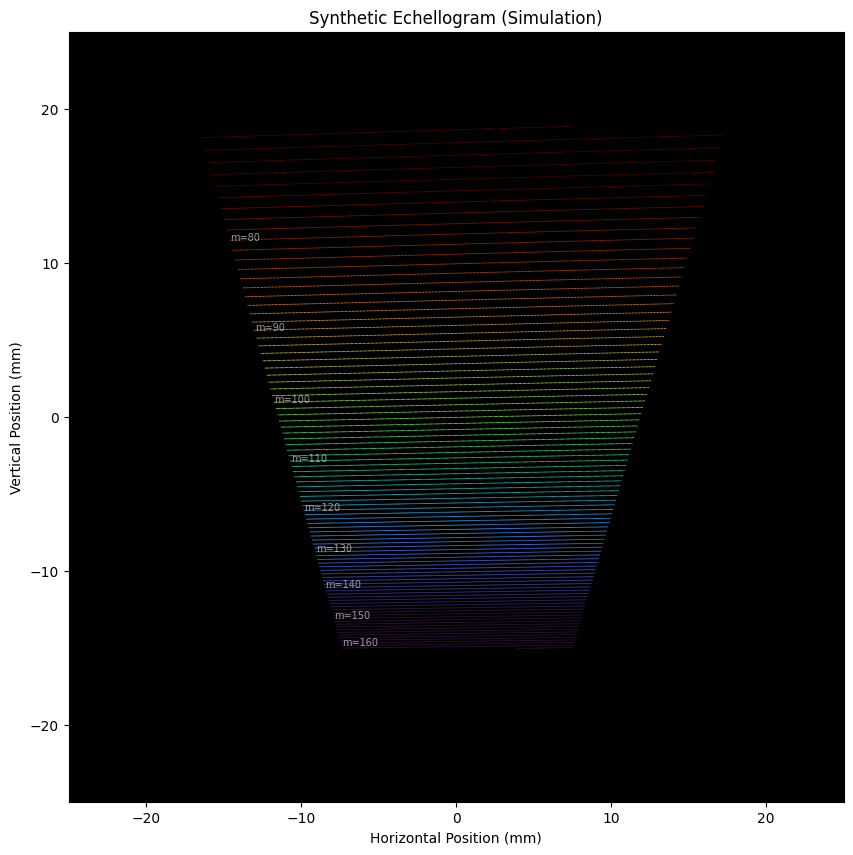

In [3]:
import numpy as np
import matplotlib.pyplot as plt

class Grating:
    """Represents a diffraction grating based on first principles."""
    def __init__(self, lines_per_mm, incidence_angle_deg):
        self.d = 1e-3 / lines_per_mm  # Convert to meters
        self.alpha = np.radians(incidence_angle_deg)

    def get_diffraction_angle(self, wavelength_m, order):
        """Solves m*lambda = d(sin(alpha) + sin(beta)) for beta."""
        sin_beta = (order * wavelength_m / self.d) - np.sin(self.alpha)

        # Filter out non-physical results (where sin_beta > 1)
        mask = np.abs(sin_beta) < 0.98
        beta = np.full_like(sin_beta, np.nan)
        beta[mask] = np.arcsin(sin_beta[mask])
        return beta

class EchelleSpectrograph:
    """Simulates a cross-dispersed spectrograph layout."""
    def __init__(self, main_grating, cross_disperser, focal_length_mm):
        self.main = main_grating
        self.cross = cross_disperser
        self.f_cam = focal_length_mm / 1000.0  # Convert to meters

    def calculate_orders(self, lambda_min, lambda_max):
        """Finds which orders m contain light within the requested range."""
        # m = d(sin alpha + sin beta) / lambda
        # Max m is at min lambda with max sin(beta)
        m_max = int((self.main.d * (np.sin(self.main.alpha) + 1)) / lambda_min)
        m_min = int((self.main.d * (np.sin(self.main.alpha) - 1)) / lambda_max)
        return range(max(1, m_min), m_max + 1)

    def generate_echellogram(self, lambda_start_nm, lambda_end_nm):
        """Simulates the 2D detector pattern."""
        l_min, l_max = lambda_start_nm * 1e-9, lambda_end_nm * 1e-9
        orders = self.calculate_orders(l_min, l_max)

        results = []
        for m in orders:
            # Calculate the blaze wavelength (center of the order)
            # In Littrow config, beta = alpha
            lambda_c = (2 * self.main.d * np.sin(self.main.alpha)) / m
            fsr = lambda_c / m

            # Generate wavelengths for this order (with 20% overlap for realism)
            waves = np.linspace(lambda_c - 0.6*fsr, lambda_c + 0.6*fsr, 300)
            # Filter to keep within global range
            waves = waves[(waves >= l_min) & (waves <= l_max)]

            if len(waves) == 0: continue

            # 1. Main Dispersion (Horizontal x)
            beta_main = self.main.get_diffraction_angle(waves, m)
            x_coords = self.f_cam * np.tan(beta_main - self.main.alpha)

            # 2. Cross Dispersion (Vertical y)
            # Cross disperser usually works in order 1
            beta_cross = self.cross.get_diffraction_angle(waves, 1)
            # Reference y-center to 550nm (Green)
            beta_ref = self.cross.get_diffraction_angle(550e-9, 1)
            y_coords = self.f_cam * np.tan(beta_cross - beta_ref)

            results.append({
                'order': m,
                'wavelengths': waves,
                'x': x_coords * 1000, # convert to mm
                'y': y_coords * 1000  # convert to mm
            })
        return results

def plot_echellogram(data, det_size_mm=50):
    """Visualization function for the generated data."""
    plt.figure(figsize=(10, 10))
    ax = plt.gca()
    ax.set_facecolor('black')

    # Wavelength-to-color mapping (Visible Range)
    norm = plt.Normalize(380e-9, 750e-9)

    for row in data:
        # Filter out NaN values from math errors
        valid = ~np.isnan(row['x']) & ~np.isnan(row['y'])
        if not np.any(valid): continue

        colors = plt.cm.turbo(norm(row['wavelengths'][valid]))
        ax.scatter(row['x'][valid], row['y'][valid], s=0.5, c=colors, edgecolors='none')

        # Label every 10th order
        if row['order'] % 10 == 0:
            ax.text(row['x'][valid][0], row['y'][valid][0], f"m={row['order']}",
                    color='white', fontsize=7, alpha=0.6)

    ax.set_xlim(-det_size_mm/2, det_size_mm/2)
    ax.set_ylim(-det_size_mm/2, det_size_mm/2)
    ax.set_title("Synthetic Echellogram (Simulation)")
    ax.set_xlabel("Horizontal Position (mm)")
    ax.set_ylabel("Vertical Position (mm)")
    plt.show()

# --- Example Usage ---

# 1. Define Components
echelle = Grating(lines_per_mm=31.6, incidence_angle_deg=63.4) # R2 Grating
cross = Grating(lines_per_mm=150, incidence_angle_deg=0)       # Cross disperser
instrument = EchelleSpectrograph(echelle, cross, focal_length_mm=500)

# 2. Run Simulation
sim_data = instrument.generate_echellogram(350, 800) # UV to Near-IR

# 3. Plot
plot_echellogram(sim_data)